# Notebook Goal

### The goal of this notebook:
1. To understand the Titanic dataset
2. To perform different feature engineering and preprocessing
3. To discover new feature that could produce good insights
   
5. Continuous iteration of data analysis for each feature engineering


### Data dictionary

|Variable|Definition|Key|
|----------|------------|-----|
| survival | Survival   | 0 = No, 1 = Yes |
| pclass | Ticket class | 1 = 1st, 2 = 2nd, 3 = 3rd |
| sex | Sex | |
| age | Age in years | |
| sibsp | # of siblings / spouses aboard the Titanic | |
| parch | # of parents / children aboard the Titanic | |
| ticket | Ticket number | |
| fare | Passenger fare | |
| cabin | Cabin number | |
| embarked | Port of Embarkation | C = Cherbourg, Q = Queenstown, S = Southampton |

In [3]:
import sys
sys.path.append("..")

In [10]:
# import .py libraries
from src import load_dataset, show_missing_entries

# eda utils
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
train_set, test_set = load_dataset()

# Test Set

In [46]:
test_set.head(3)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q


In [47]:
test_set.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


In [49]:
show_missing_entries(test_set)

,Column,Missing,Percentage
9,Cabin,327,78.23
4,Age,86,20.57
8,Fare,1,0.24


# Train Set

In [12]:
train_set.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [13]:
train_set.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [14]:
show_missing_entries(train_set)

,Column,Missing,Percentage
10,Cabin,687,77.10
5,Age,177,19.87
11,Embarked,2,0.22


## Sex

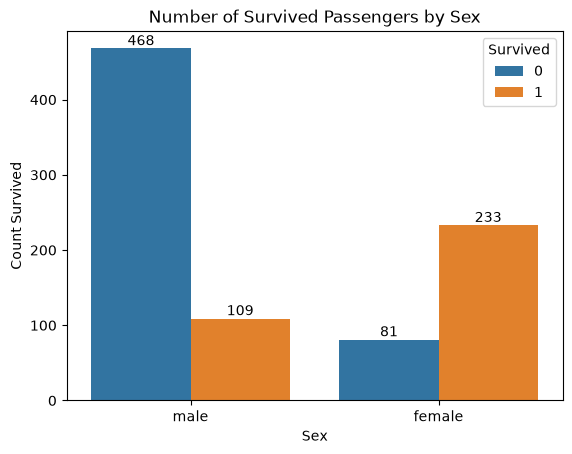

In [15]:
bar = sns.countplot(train_set, x = "Sex", hue="Survived")

for container in bar.containers:
    bar.bar_label(container)
    
plt.title('Number of Survived Passengers by Sex')
plt.xlabel('Sex')
plt.ylabel('Count Survived')
plt.show()

Text(0, 0.5, 'Number of Passengers')

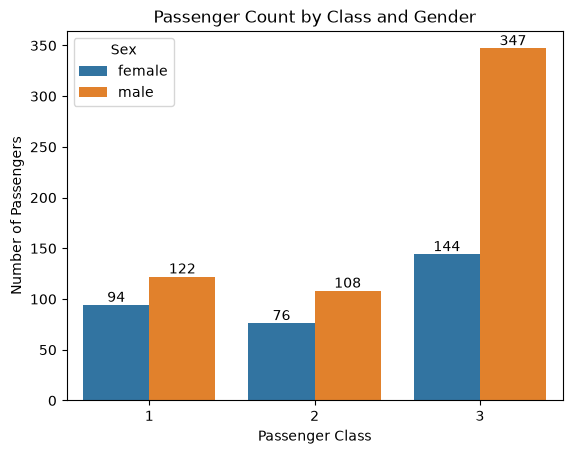

In [27]:
bar = sns.countplot(train_set, x = "Pclass", hue="Sex")

for container in bar.containers:
    bar.bar_label(container)
    
plt.title("Passenger Count by Class and Gender")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

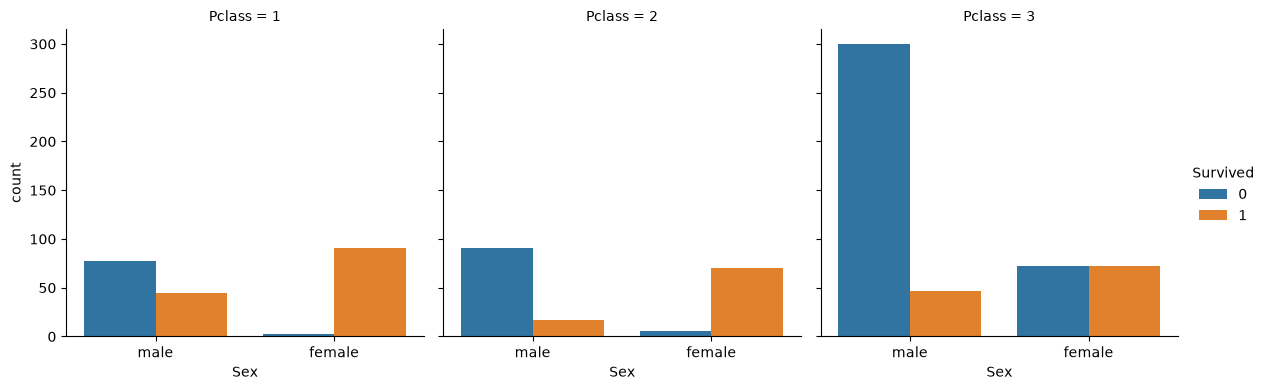

In [29]:
sns.catplot(
    data=train_set,
    x='Sex',
    hue='Survived',
    col='Pclass',
    kind='count',
    height=4,
    aspect=1
)

## Fare

<Axes: xlabel='Fare', ylabel='Count'>

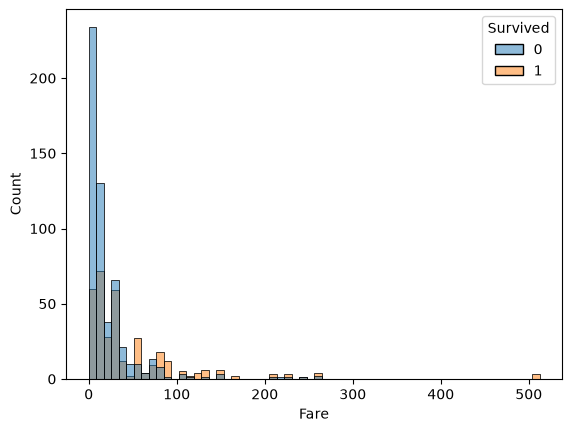

In [34]:
sns.histplot(train_set, x = "Fare", hue="Survived")

In [33]:
df = train_set.copy()
df[df['Fare'] > 400]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C


In [36]:
train_set.groupby(['Pclass','Sex'])['Fare'].mean()

Pclass  Sex   
1       female    106.125798
        male       67.226127
2       female     21.970121
        male       19.741782
3       female     16.118810
        male       12.661633
Name: Fare, dtype: float64

Text(0.5, 1.0, 'Survived = False')

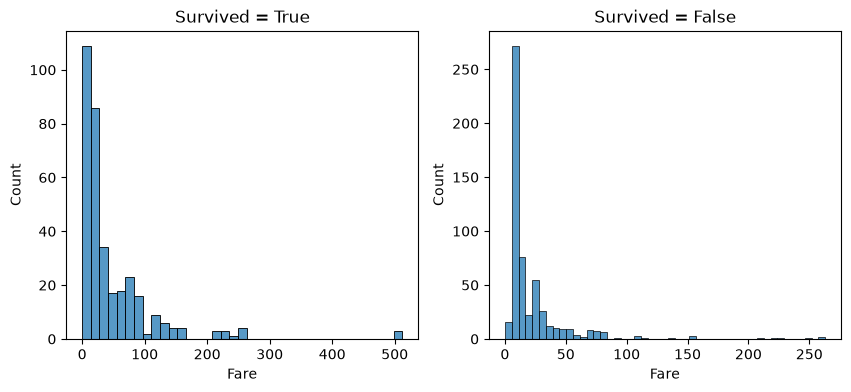

In [56]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

sns.histplot(train_set[train_set['Survived'] == 1], x = "Fare", ax=axs[0])
axs[0].set_title("Survived = True")

sns.histplot(train_set[train_set['Survived'] == 0], x = "Fare", ax=axs[1])
axs[1].set_title("Survived = False")

## Embarked

In [37]:
train_set[train_set['Embarked'].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


**According to historical facts, Miss Amelie and Mrs. George Nelson embarked on Southampton**

In [38]:
train_set['Embarked'] = train_set['Embarked'].fillna('S')

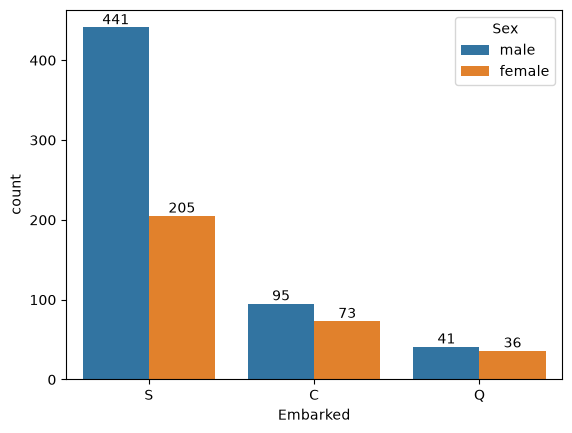

In [40]:
bar = sns.countplot(train_set, x = "Embarked", hue="Sex")

for container in bar.containers:
    bar.bar_label(container)

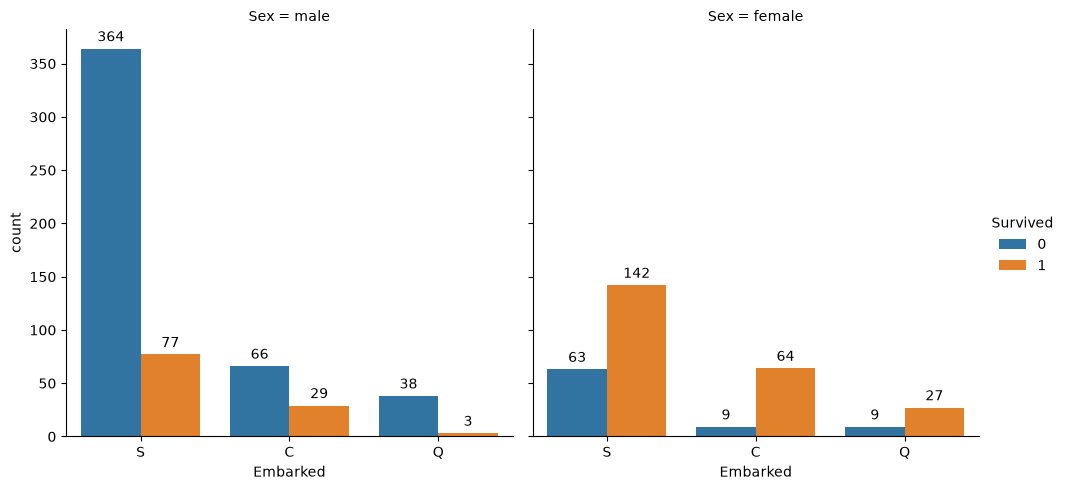

In [44]:
g = sns.catplot(train_set, x = "Embarked", hue="Survived", kind="count", col="Sex")

for ax in g.axes.flat:
    # Loop through the bar containers within that specific subplot
    for container in ax.containers:
        ax.bar_label(container, fontsize=10, padding=3)

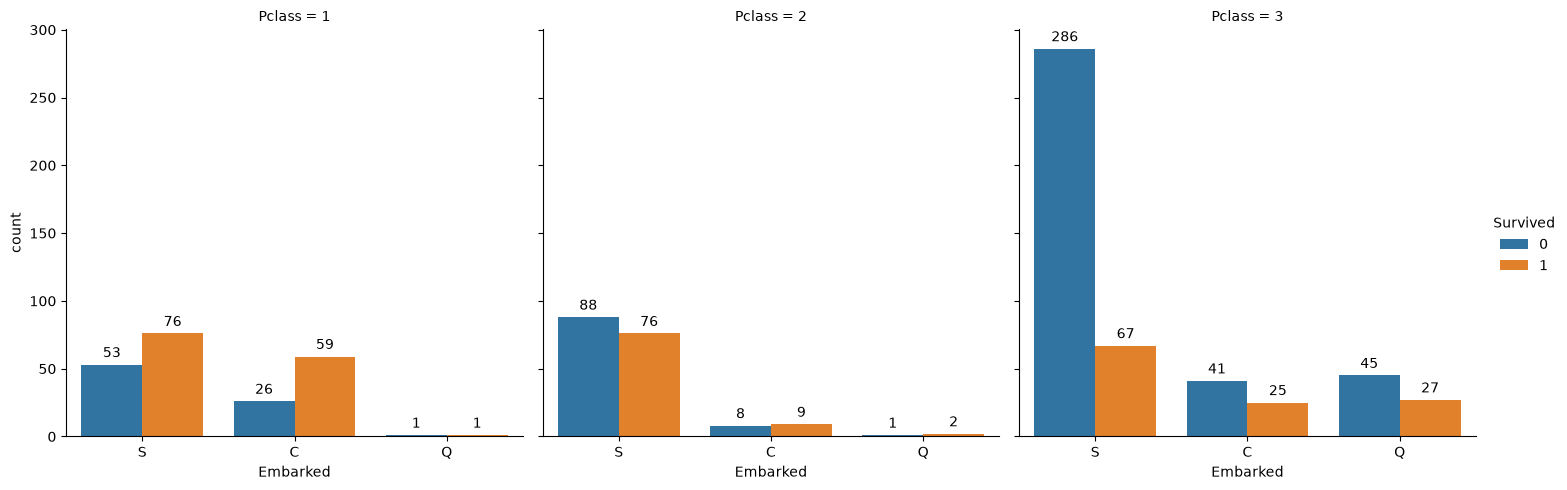

In [45]:
g = sns.catplot(train_set, x = "Embarked", hue="Survived", kind="count", col="Pclass")

for ax in g.axes.flat:
    # Loop through the bar containers within that specific subplot
    for container in ax.containers:
        ax.bar_label(container, fontsize=10, padding=3)

## Age

In [58]:
train_set.corr(numeric_only=True)['Age'].sort_values(ascending=False)

Age            1.000000
Fare           0.096067
PassengerId    0.036847
Survived      -0.077221
Parch         -0.189119
SibSp         -0.308247
Pclass        -0.369226
Name: Age, dtype: float64

**Pclass has the highest magnitude of correlation with Age. Thus, it is a good candidates for imputing missing Age values. To make it more distinct and meaningful, I can also use Sex.**

<Axes: xlabel='Age', ylabel='Count'>

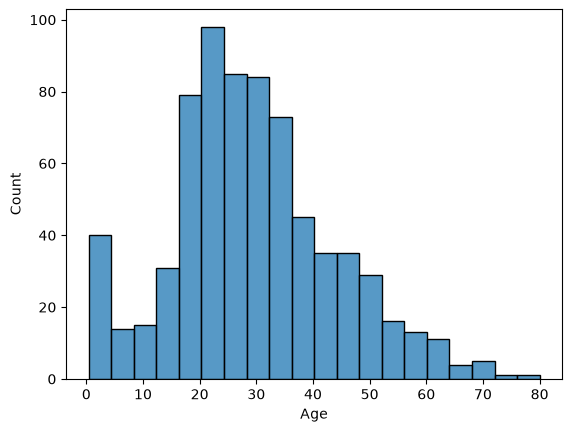

In [60]:
# current distribution
sns.histplot(train_set, x="Age")

In [61]:
age_median_by_pclass_sex = train_set.groupby(['Pclass', 'Sex'])['Age'].transform('median')

In [64]:
train_set['Age'] = df['Age'].fillna(age_median_by_pclass_sex)

<Axes: xlabel='Age', ylabel='Count'>

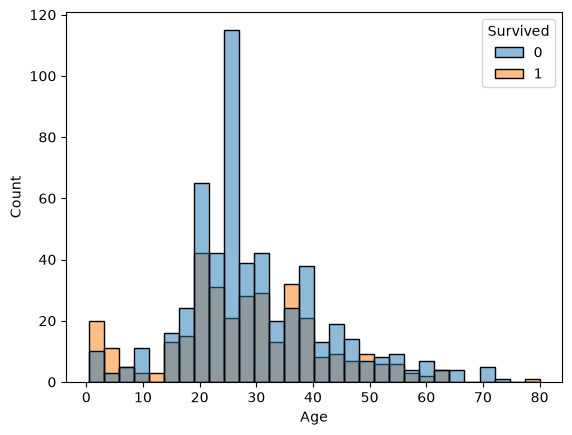

In [69]:
# updated/imputed distribution
sns.histplot(train_set, x="Age", hue='Survived', bins=30)

<Axes: xlabel='Age', ylabel='count'>

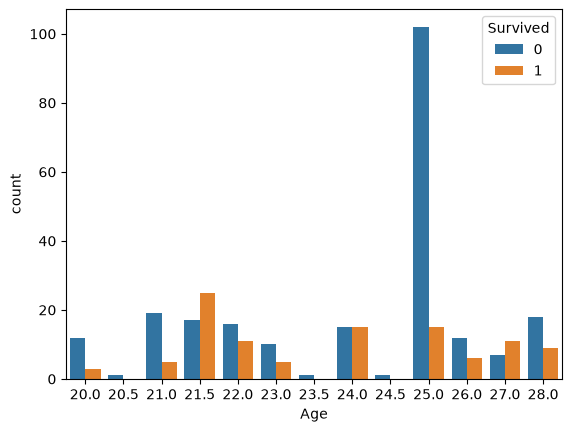

In [73]:
df = train_set[(train_set['Age'] >= 20) & (train_set['Age'] <= 28)]
sns.countplot(df, x="Age", hue="Survived")